In [ ]:
import sys; sys.path.insert(0, '../Sparse_Cholesky')

In [59]:
from cholesky import *
from ordering import *
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

torch.set_default_dtype(torch.float64)

# Parameters for the viscous Burgers equation
N = 32  # Number of grid points
L = 1.0  # Length of the domain [0, 1]
rho = 100  # Sparsity factor defined by ln(N/epsilon)
x = torch.linspace(0, L, N + 1)[:-1]  # Equidistant grid points
dx = x[1] - x[0]  # Grid spacing
x_ten = x.unsqueeze(1)
# Time parameters
T = 1.0       # Final time
dt = 0.01     # Time step size
N_T = 100  # Number of Time Points
nu = 0.01      # Viscosity

#  Parameters for Sparse Cholesky
Perm, lengths = maximin(x_ten)  # Calculating MaxMin Ordering
sparsity = sparsity_pattern(x_ten[Perm], lengths, rho)  # Calculating the sparsity pattern
nonzeros_indices = non_zeros(N, sparsity)  # Calculating the non zero indices

# Parameters for the Training
num_newton_iter = 5  # Number of classical Newton iterations for Data generation
num_realizations = 120  # Number of realizations
num_training = num_realizations * num_newton_iter - 120  # Number of training samples
num_folds = 5  # For cross-validation
lambda_reg = 0.01  # Regularizer for the Newton-Iteration


# Gaussian Process class with learnable nugget
class GaussianProcess(nn.Module):
    def __init__(self, length_scale=1.0, nugget_init=1e-6, nu=3 / 2):
        super(GaussianProcess, self).__init__()
        self.length_scale = nn.Parameter(torch.ones(N) * length_scale)
        # self.length_scale = nn.Parameter(torch.ones(1) * length_scale)
        # self.nugget = nn.Parameter(torch.tensor(nugget_init))
        self.nugget = torch.tensor(nugget_init)
        self.nu = nu

    def matern_kernel(self, X1, X2):
        # Compute pairwise Euclidean distance between points in scaled X1 and X2
        X1_scaled = X1 * self.length_scale
        X2_scaled = X2 * self.length_scale
        pairwise_dists = torch.cdist(X1_scaled, X2_scaled, p=2)

        if self.nu == 3 / 2:
            scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists
            K = (1 + scale) * torch.exp(-scale)
        else:
            raise ValueError("Only nu=3/2 is supported.")
        return K

    def fit(self, X_train, y_train):
        # Kernel matrices with learnable nugget
        K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
        # L = torch.linalg.cholesky(K_train)
        # alpha_train = torch.linalg.solve_triangular(L, y_train, upper=False)
        alpha_train = torch.linalg.solve(K_train, y_train)
        self.alpha_train = alpha_train
        self.X_train = X_train

    def forward(self, X_val):
        K_val_train = self.matern_kernel(X_val, self.X_train)
        y_pred_val = K_val_train @ self.alpha_train
        return y_pred_val

    # def forward(self, X_train, y_train, X_val):
    #     # Kernel matrices with learnable nugget
    #     K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
    #     # L = torch.linalg.cholesky(K_train)
    #     # alpha_train = torch.linalg.solve_triangular(L, y_train, upper=False)
    #     alpha_train = torch.linalg.solve(K_train, y_train)
    #
    #     K_val_train = self.matern_kernel(X_val, X_train)
    #     y_pred_val = K_val_train @ alpha_train
    #     return y_pred_val


# Generate the covariance matrix using the Matérn kernel
def generate_covariance_matrix(kernel_func, x, length_scale):
    return kernel_func(x.unsqueeze(1), x.unsqueeze(1), length_scale)


# Generate f and u based on GP(0, K)
def generate_f_u_from_gp(num_realizations, N, kernel_func, length_scale, x):
    K = kernel_func(x.unsqueeze(1), x.unsqueeze(1), length_scale)
    K = K + 1e-3 * torch.eye(K.shape[0])
    L = torch.linalg.cholesky(K)
    f_realizations = torch.randn(num_realizations, N)
    u_realizations = torch.randn(num_realizations, N)
    f_realizations = (L @ f_realizations.T).T
    u_realizations = (L @ u_realizations.T).T
    # mean = torch.zeros(N)
    # f_realizations = torch.stack([torch.distributions.MultivariateNormal(mean, K).rsample() for _ in range(num_realizations)])
    # u_realizations = torch.stack([torch.distributions.MultivariateNormal(mean, K).rsample() for _ in range(num_realizations)])
    return f_realizations, u_realizations


# Laplacian operator with periodic BC
def laplacian_matrix(N, dx):
    L = torch.zeros((N, N))
    for i in range(N):
        L[i, i] = -2 / dx**2
        L[i, (i+1) % N] = 1 / dx**2  # Periodic BC
        L[i, (i-1) % N] = 1 / dx**2  # Periodic BC
    return L


# Convection matrix
def convection_matrix(u, N, dx):
    C = torch.zeros((N, N))
    for i in range(N):
        C[i, (i+1) % N] = u[i] / (2 * dx)  # Forward difference
        C[i, (i-1) % N] = -u[i] / (2 * dx) # Backward difference
    return C

# Residual
def residual(u_next, u_prev, L, C, dt):
    return u_next - u_prev + dt * (C @ u_next - nu * L @ u_next)


def jacobian(u_next, L, dx, dt, nu):
    
    N = len(u_next)
    J = torch.eye(N) + dt * (-nu * L)  # Start with diffusion term

    # Add convection term
    for i in range(N):
        ip1 = (i + 1) % N  # Periodic BC
        im1 = (i - 1) % N
        
        # Diagonal term
        J[i, i] += dt * (u_next[ip1] - u_next[im1]) / (2 * dx)
        
        # Off-diagonal terms
        J[i, ip1] += dt * u_next[i] / (2 * dx)
        J[i, im1] -= dt * u_next[i] / (2 * dx)

    return J



# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classical_newton_method(f, u_prev, A_laplace, max_iter, learning_rate):
    v_n =u_prev.clone()

    # Initialize a matrix to store the solution at each iteration
    solutions_matrix = torch.zeros((5 + 1, u_prev.numel()))  # numel() gives the number of elements in v0

    # Store the current solution in the matrix
    solutions_matrix[0, :] = v_n.view(-1)  # Store the flattened solution
    

    for i in range(max_iter):
        j=0
        # Solve the Newton iteration
        C = convection_matrix(v_n, N, dx)
        res = residual(v_n, u_prev, A_laplace, C, dt)
        J = jacobian(v_n, A_laplace, dx, dt, nu)
        
        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()

        # Store the current solution in the matrix
        if i > 0 and i % 10 == 0:
            j=j+1
            solutions_matrix[j, :] = v_n.view(-1)  # Store the flattened solution

        # print(f"Iteration {i + 1}, Update: {delta_v.mean().item()}")

    return solutions_matrix



# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classic_newton_method(f, u_prev, A_laplace, max_iter, learning_rate):
    v_n =u_prev.clone()

    for i in range(max_iter):
        # Solve the Newton iteration
        C = convection_matrix(v_n, N, dx)
        res = residual(v_n, u_prev, A_laplace, C, dt)
        J = jacobian(v_n, A_laplace, dx, dt, nu)
        
        delta_v = torch.linalg.solve(J, -res)
        v_n = v_n + learning_rate * delta_v.squeeze()

    return v_n

# Solves the equation via classical Newton iteration. u0 intial guess (typically = u_prev), u_prev previous time step, C convection matrix, L laplacian, max_inter Newton iterations, learning_rate is the damping term
def classic_newton_line_search(N, f, u_prev, A_laplace, max_iter, c1, beta, learning_rate):
    v_n =u_prev.clone()

    for i in range(max_iter):
        # Solve the Newton iteration
        C = convection_matrix(v_n, N, dx)
        F_n = residual(v_n, u_prev, A_laplace, C, dt)
        P = jacobian(v_n, A_laplace, dx, dt, nu)
        
        delta_v = torch.linalg.solve(P, F_n)
        
        alpha = learning_rate  # Initial step size 
        v_trial = v_n - alpha * delta_v 
        F_n_delta = residual(v_trial, u_prev, A_laplace, C, dt) # Evaluate F at current guess
        
        # F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f  

        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(F_n, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            F_n_delta = residual(v_trial, u_prev, A_laplace, C, dt) # Evaluate F at current guess

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v
        
        # # Check for convergence
        # if torch.norm(F_n) < 1e-6:  # Convergence tolerance
        #     break

        # Free intermediate tensors
        del F_n, F_n_delta, P, delta_v
        torch.cuda.empty_cache()

    return v_n



# Invert matrix using Cholesky decomposition
def cholesky_inverse(A):
    L = torch.linalg.cholesky(A + 1e-8 * torch.eye(len(A)), upper=False)
    L_inv = torch.inverse(L)
    # A_inv = L_inv.T @ L_inv  # A_inv = (L_inv.T) * (L_inv)
    return L_inv



def newton_line_search(f, v0, A_laplace, max_iter, c1, beta):
    v_n = v0.clone()

    for i in range(max_iter):

        # Solve the Newton iteration
        delta_v = solve_system_linalg(f, v_n, A_laplace)
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f
        d = P.T @ F_n
        alpha = 1  # Initial step size
        v_trial = v_n + alpha * delta_v
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f  # Evaluate F at current guess

        # for iteration in range(3):  # Limit to a maximum of 3 iterations
        #     if torch.norm(F_n_delta)**2 <= torch.norm(F_n)**2 + 2 * c1 * alpha * torch.dot(d, delta_v):
        #         break  # Exit the loop if the condition is met
        #     alpha *= beta  # Reduce step size if condition is not met

        while torch.norm(F_n_delta) ** 2 >= torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n + alpha * delta_v
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n + alpha * delta_v

    return v_n


def classical_newton_method_reg(f, v0, A_laplace, max_iter, lambda_reg, learning_rate):
    v_n = v0.clone()

    # Initialize a matrix to store the solution at each iteration
    solutions_matrix = torch.zeros((max_iter + 1, v0.numel()))  # numel() gives the number of elements in v0

    # Store the current solution in the matrix
    solutions_matrix[0, :] = v_n.view(-1)  # Store the flattened solution

    for i in range(max_iter):
        # Solve the Newton iteration
        delta_v = solve_reg_system(f, v_n, A_laplace, lambda_reg)
        # delta_v = solve_system_linalg(f,v_n,A_laplace)
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + learning_rate * delta_v.squeeze()

        # Store the current solution in the matrix
        solutions_matrix[i + 1, :] = v_n.view(-1)  # Store the flattened solution

        # print(f"Iteration {i + 1}, Update: {delta_v.mean().item()}")

    return solutions_matrix


def inverse_map(u_realizations, N, lambda_reg):
    M = u_realizations.shape[0]

    # List to store the flattened inverse matrices
    flattened_inverses = []

    # Loop over each realization
    for i in range(M):
        u_i = u_realizations[i, :]  # ith function

        # Construct the matrix A_i = -A_laplace + diag(3 * u_i^2)
        A = -A_laplace + torch.diag(3 * Factor * u_i ** 2)
        A_T = A.T
        A_i = lambda_reg * torch.eye(A.size(0)) + A_T @ A

        # Compute the inverse using Cholesky decomposition
        try:
            L_inv = cholesky_inverse(A_i)
        except RuntimeError:
            print(f"Matrix {i} is not positive definite. Skipping.")
            continue

        # Flatten the inverse matrix and store it
        flattened_inverses.append(L_inv.flatten())

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses)

    return flattened_inverses



def inverse_map_sparse_cholesky(u_realizations, N, A_laplace, lambda_reg, Perm, sparsity):
    M = u_realizations.shape[0]

    # List to store the flattened inverse matrices
    flattened_inverses = []

    # Loop over each realization
    for i in range(M):
        u = u_realizations[i, :]  # ith function
        C = convection_matrix(u, N, dx)
        
        # Construct the matrix A_i
        J = jacobian(u, A_laplace, dx, dt, nu) 
        A_i = lambda_reg * torch.eye(N) + J.T @ J

        # Compute the inverse using Cholesky decomposition
        U_sparse = sparse_cholesky(A_i, Perm, sparsity)
        sparse_elements = U_sparse._values()

        # Store the flatten inverses
        flattened_inverses.append(sparse_elements)

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses)

    return flattened_inverses


# 
# # Solve the system A v = b for each realization
# def solve_system_linalg(f, u, A_laplace):
#     A = -A_laplace + torch.diag(3 * Factor * u ** 2)
#     b = f + A_laplace @ u - Factor * u ** 3
#     # Mat = cholesky_inverse(A)
#     # v = Mat @ b 
#     v = torch.linalg.solve(A, b)
#     return v
# 
# 
# # Solve the system A v = b for each realization
# def solve_system_cholesky(f, u, A_laplace):
#     A = -A_laplace + torch.diag(3 * Factor * u ** 2)
#     b = f + A_laplace @ u - Factor * u ** 3
#     Mat = cholesky_inverse(A)
#     v = Mat @ b
#     # v = torch.linalg.solve(A, b)
#     return v
# 
# 
# # Solve the regularized system (lambda I +A'A) v = A' b for each realization
# def solve_reg_system(f, u, A_laplace, lambda_reg):
#     tau_prime_u = 3 * Factor * u ** 2
#     A = -A_laplace + torch.diag(tau_prime_u)
#     b = f + A_laplace @ u - Factor * u ** 3
#     A_T = A.T
#     # lambda I is the regularization term, and A'A is the normal equation term
#     A_reg = lambda_reg * torch.eye(A.size(0)) + A_T @ A
#     # Right-hand side for the system
#     rhs = A_T @ b
#     # Solve the system (lambda I + A'A) v = A'b
#     v = torch.linalg.solve(A_reg, rhs)
# 
#     return v
# 
# 
# # Solve the regularized system (lambda I +A'A) v = A' b for each realization
# def solve_system_min(f, u, A_laplace):
#     tau_prime_u = 3 * Factor * u ** 2
#     tau_two_prime_u = 6 * Factor * u
#     A = -A_laplace + torch.diag(tau_prime_u)
#     b = f + A_laplace @ u - Factor * u ** 3
#     # Take the absolute value of `a`
#     abs_a = torch.abs(tau_two_prime_u * b)
#     # Create a tensor with the same shape as `a`, filled with 1s
#     # ones = torch.ones_like(abs_a)
#     # Compute element-wise maximum between `abs_a` and 1
#     # min = torch.maximum(abs_a, ones)
#     # I = torch.diag(abs_a)
#     ones = torch.ones_like(abs_a)
#     I = torch.diag(ones) * torch.mean(abs_a)
#     A_T = A.T
#     # lambda I is the regularization term, and A'A is the normal equation term
#     A_reg = I + A_T @ A
#     # Right-hand side for the system
#     rhs = A_T @ b
#     # Solve the system (lambda I + A'A) v = A'b
#     v = torch.linalg.solve(A_reg, rhs)
# 
#     return v


# Cross-validation with GP kernel and alpha optimization using KFold
def cross_validation_loss(model, X, y, num_folds=5):
    kf = KFold(n_splits=num_folds)
    l2_losses = 0

    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # GP prediction on validation data
        model.fit(X_train, y_train)
        y_pred_val = model(X_val)

        # Compute the relative L2 loss
        l2_loss = torch.mean(torch.norm(y_val - y_pred_val, dim=1) / torch.norm(y_val, dim=1))
        l2_losses += l2_loss

    # Return the mean loss across all folds
    return l2_losses / num_folds


# Train step
def train_step(model, X, y, optimizer):
    optimizer.zero_grad()
    loss_value = cross_validation_loss(model, X, y, num_folds)
    loss_value.backward()
    optimizer.step()
    return loss_value


def periodic_kernel(X1, X2, length_scale=1, period=1):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    sine_term = torch.sin(torch.pi * pairwise_dists / period)
    K = torch.exp(-2 * sine_term ** 2 / length_scale ** 2)
    return K


# Define the kernel function
def matern_kernel(X1, X2, length_scale):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists / length_scale
    K = (1 + scale) * torch.exp(-scale)
    return K

In [60]:
# Instantiate the GP model and Adam optimizer
optimizer = [None] * 2
gp_model = [None] * 2

# Train the model using Adam and cross-validation
num_steps = 90  # Number of optimization steps

# Define a matrix containing the lambda values and the corresponding cross-validation error
alpha_error_matrix = torch.zeros((2, num_steps))

# Laplacian matrix for the grid
A_laplace = laplacian_matrix(N, dx)


# Generate data for f and u based on GP(0, K)
f_realizations, u_realizations = generate_f_u_from_gp(num_realizations, N, periodic_kernel, length_scale=0.2, x=x)

# Solve the system for each realization with up to max_iter Newton iterations.
v_solutions = torch.cat(
    [classical_newton_method(f_realizations[j], u_realizations[j], A_laplace, max_iter=51, learning_rate=1)
     for j in range(num_realizations)], dim=0)

f = torch.repeat_interleave(f_realizations, repeats=num_newton_iter, dim=0)
X_data = v_solutions

# y_data_groundtruth = inverse_map_tri(v_solutions, N, lambda_reg)
y_data = inverse_map_sparse_cholesky(v_solutions, N, A_laplace, lambda_reg, Perm, sparsity)

print(X_data.shape, y_data.shape)
# # Create new instances for each model
# gp_model[0] = GaussianProcess(length_scale=1.0)
# 
# # Load each model's state_dict back from the saved files
# gp_model[0].load_state_dict(torch.load(f"gaussian_process_model_burgers_nu={nu}_flow*4.pth", weights_only=True))
# gp_model[0].eval()  # Set each model to evaluation mode

torch.Size([720, 32]) torch.Size([720, 528])


Step 0, Loss: 0.30071792278085074, Rel. L2 err: 0.29266703523190873, L2 err: 1.4479017395665978, Learning Rate: 0.01, Lambda = 0.01
Step 1, Loss: 0.2983663795876526, Rel. L2 err: 0.2898488642831071, L2 err: 1.4340690801253193, Learning Rate: 0.01, Lambda = 0.01
Step 2, Loss: 0.2958692797452625, Rel. L2 err: 0.28687120794139437, L2 err: 1.41945214936031, Learning Rate: 0.01, Lambda = 0.01
Step 3, Loss: 0.29321956441238434, Rel. L2 err: 0.28372830365596446, L2 err: 1.4040224469760487, Learning Rate: 0.01, Lambda = 0.01
Step 4, Loss: 0.29041020374444526, Rel. L2 err: 0.2804147665534934, L2 err: 1.387753302097429, Learning Rate: 0.01, Lambda = 0.01
Step 5, Loss: 0.28743429638480145, Rel. L2 err: 0.2769257524344131, L2 err: 1.3706206693423182, Learning Rate: 0.01, Lambda = 0.01
Step 6, Loss: 0.2842851886441186, Rel. L2 err: 0.27325717603177396, L2 err: 1.3526041930846369, Learning Rate: 0.01, Lambda = 0.01
Step 7, Loss: 0.28095661598727933, Rel. L2 err: 0.2694060385413304, L2 err: 1.3336888

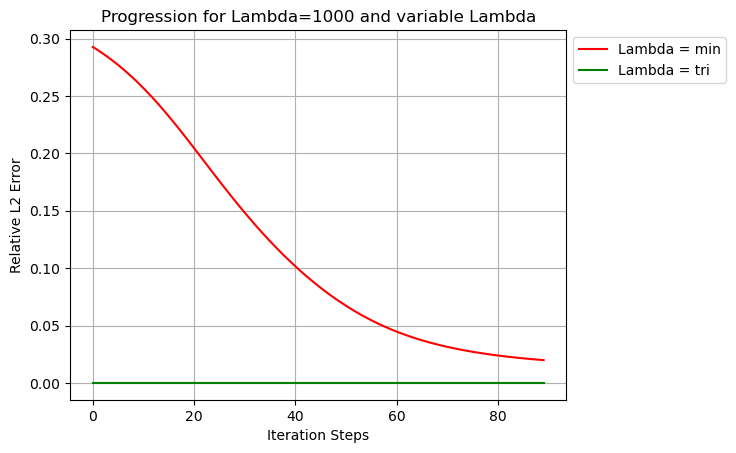

In [36]:

# Instantiate the GP model and Adam optimizer
gp_model[0] = GaussianProcess(length_scale=1.0)
optimizer[0] = optim.Adam(gp_model[0].parameters(), lr=0.01)

for step in range(num_steps):
    loss_value = train_step(gp_model[0], X_data[:num_training], y_data[:num_training], optimizer[0])

    # Step the schedulerloss_value
    # scheduler.step(loss_value)

    # Predict on the test set
    X_train = X_data[:num_training]
    y_train = y_data[:num_training]
    X_test = X_data[num_training:]
    y_pred_test = y_data[num_training:]

    with torch.no_grad():
        gp_model[0].fit(X_train, y_train)
        y_pred_test_pca = gp_model[0](X_test)

    # Calculate relative L2 error
    rl2error = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1) / torch.norm(y_pred_test, dim=1)).item()
    # r2error_A_inv = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1) / torch.norm(y_pred_test, dim=1)).item()
    l2error = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1)).item()
    current_lr = optimizer[0].param_groups[0]['lr']
    alpha_error_matrix[0, step] = rl2error

    print(
        f"Step {step}, Loss: {loss_value.item()}, Rel. L2 err: {rl2error}, L2 err: {l2error}, Learning Rate: {current_lr}, Lambda = {lambda_reg}")


# Plotting
def plot_results(matrix, num_steps):
    # Convert matrix to numpy for easier plotting
    result_numpy = matrix.numpy()

    # Define a list of colors for each alpha (7 values, 7 colors)
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Red, Green, Blue, Cyan, Magenta, Yellow, Black

    # Plot for each alpha
    plt.plot(range(num_steps), result_numpy[0, :], label=f'Lambda = min', color=colors[0])
    plt.plot(range(num_steps), result_numpy[1, :], label=f'Lambda = tri', color=colors[1])

    # Add labels and legend
    plt.xlabel('Iteration Steps')
    plt.ylabel('Relative L2 Error')
    plt.title('Progression for Lambda=1000 and variable Lambda')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.show()


# Call the plot function
plot_results(alpha_error_matrix, num_steps)


# Save the model for further usage
torch.save(gp_model[0].state_dict(), f"gaussian_process_model_burgers_nu={nu}_flow*10.pth")

In [37]:
# # Save the model for further usage
# torch.save(gp_model[0].state_dict(), f"gaussian_process_model_burgers_nu={nu}.pth")

In [48]:
def deep_newton_method_line_search(model, f, v0, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor
        tmp = model.forward(X_train)

        # Create an empty matrix of desired size
        L_inv = torch.zeros((N, N), dtype=tmp.dtype)

        # Create a mask for the lower triangular part
        mask = torch.tril(torch.ones((N, N), dtype=torch.bool))

        # Fill in the lower triangular part using the vector
        L_inv[mask] = tmp

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = L_inv.T @ L_inv

        # Compute F and the Gradient of F at v_n
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)

        # Compute the right-hand side of the linear system
        d = P.T @ F_n

        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d

        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f  # Evaluate F at current guess

        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n


def deep_newton_method_sparse_cholesky(model, N, u, u_prev, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = u_prev.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor
        with torch.no_grad(): # Disable gradients for inference
            U_sparse = model.forward(X_train)

        # Convert sparse tensor to dense for validation
        nonzeros_indices = non_zeros(N, sparsity)  # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)

        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]
                
        # Compute the residual and its Jacobian
        C = convection_matrix(v_n, N, dx)
        F_n = residual(v_n, u_prev, A_laplace, C, dt)
        P = jacobian(v_n, A_laplace, dx, dt, nu)

        # # Compute F and the Gradient of F at v_n
        # F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f
        # P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)

        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        d = d.detach()  # Detach from computational graph
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        delta_v = delta_v.detach()
        

        alpha = learning_rate  # Initial step size 
        v_trial = v_n - alpha * delta_v 
        F_n_delta = residual(v_trial, u_prev, A_laplace, C, dt) # Evaluate F at current guess
        
        # F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f  
        # for _ in range(10):  # Maximum of 5 iterations
        #     if torch.norm(F_n_delta) ** 2 <= torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
        #         break  # Exit the loop if the condition is satisfied
        #     alpha *= beta  # Reduce step size
        #     v_trial = v_n - alpha * delta_v
        #     F_n_delta = residual(v_trial, u_prev, A_laplace, C, dt)  # Evaluate F at current guess
    
        while torch.norm(F_n_delta) ** 2 > torch.norm(F_n) ** 2 + 2 * c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v
            F_n_delta = residual(v_trial, u_prev, A_laplace, C, dt) # Evaluate F at current guess

            # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

        # # Cleanup intermediate variables to free memory
        # del F_n, P, d, delta_v, F_n_delta, A_inv, U_dense, sparse_tensor
        # torch.cuda.empty_cache()
        
    return v_n



def time_forward_method_deep(model, N, N_T, u, u0, A_laplace, max_iter, c1, beta, learning_rate):
    
    u_sol = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
    u_sol[:,0] = u0
    
    for i in range(N_T-1):
        u_sol[:, i+1] = deep_newton_method_sparse_cholesky(model, N, u, u_sol[:, i], A_laplace, max_iter, c1, beta, learning_rate)
    return u_sol



def time_forward_method_classic(u, u_prev, A_laplace, max_iter, learning_rate):
    
    u_sol = torch.zeros((N, N_T), dtype=u_prev.dtype, device=u_prev.device)
    u_sol[:,0] = u_prev
    
    for i in range(N_T-1):
        u_sol[:, i+1] = classic_newton_method(u, u_sol[:, i], A_laplace, max_iter, learning_rate)
        
    return u_sol



def time_forward_method_classic_line_search(N, u, u_prev, A_laplace, max_iter, c1, beta, learning_rate):
    
    u_sol = torch.zeros((N, N_T), dtype=u_prev.dtype, device=u_prev.device)
    u_sol[:,0] = u_prev
    
    for i in range(N_T-1):
        u_sol[:, i+1] = classic_newton_line_search(N, u, u_sol[:, i], A_laplace, max_iter, c1, beta, learning_rate) 
        
    return u_sol



In [39]:
# Checking the classical numerical scheme 

functions = [
    lambda x: x,                                            # 0 Linear function
    lambda x: x**2,                                         # 1 Quadratic function
    lambda x: torch.sin(2 * torch.pi * x),                     # 2 Sine function
    lambda x: torch.cos(2 * torch.pi * x),                  # 3 Cosine function
    lambda x: torch.exp(torch.sin(2 * torch.pi * x)),       # 4 Exponential function
    lambda x: torch.log(x + 1),                             # 5 Logarithmic function (shifted to avoid log(0))
    lambda x: torch.abs(x - 0.5),                           # 6 Absolute value centered at 0.5
    lambda x: torch.sqrt(x),                                # 7 Square root function
    lambda x: torch.heaviside(x - 0.5, torch.tensor(0.0)),  # 8  Heaviside step function at 0.5
    lambda x: torch.sin(5 * torch.pi * x) * torch.exp(-x),  # 9 Damped sine wave
    lambda x: torch.tanh(x),                                # 10 Tanh
    lambda x: torch.sigmoid(x),                             # 11 Sigmoid 
    lambda x: torch.sin(2 * torch.pi * x) + torch.cos(4 * torch.pi * x) ** 2, # 12
    lambda x: torch.sin(10* torch.pi * x),                   # 13
    lambda x: x**2 * (1 - x)**3+10,                          # 14
    lambda x: x**5 * (1 - x)**3,                            # 15
]

u_initial = functions[2]
u0 = -torch.vmap(u_initial)(x)
N_T = 100
A_laplace = laplacian_matrix(N, dx)
f = torch.zeros(N)  

u_sol = time_forward_method_classic(f, u0, A_laplace, max_iter=300, learning_rate=1.0)

In [40]:
# X_train = X_data[:num_training]
# y_train = y_data[:num_training]
# gp_model[0].fit(X_train, y_train)   

In [42]:
M_T = 100

# u_pred = time_forward_method_deep(gp_model[0], N, M_T, u = f, u0 = u0, A_laplace = A_laplace, max_iter=300, c1=1e-4, beta=0.3, learning_rate=1) 
u_sol = time_forward_method_classic(f, u0, A_laplace, max_iter=300, learning_rate=1.0)

u_pred = torch.zeros((N, N_T), dtype=u0.dtype, device=u0.device)
u_pred[:,0] = u0

for i in range(M_T-1):
    u_pred[:, i+1] = deep_newton_method_sparse_cholesky(gp_model[0], N, f, u_pred[:, i], A_laplace = A_laplace, max_iter=100, c1=1e-4, beta=0.3, learning_rate=1)
 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98


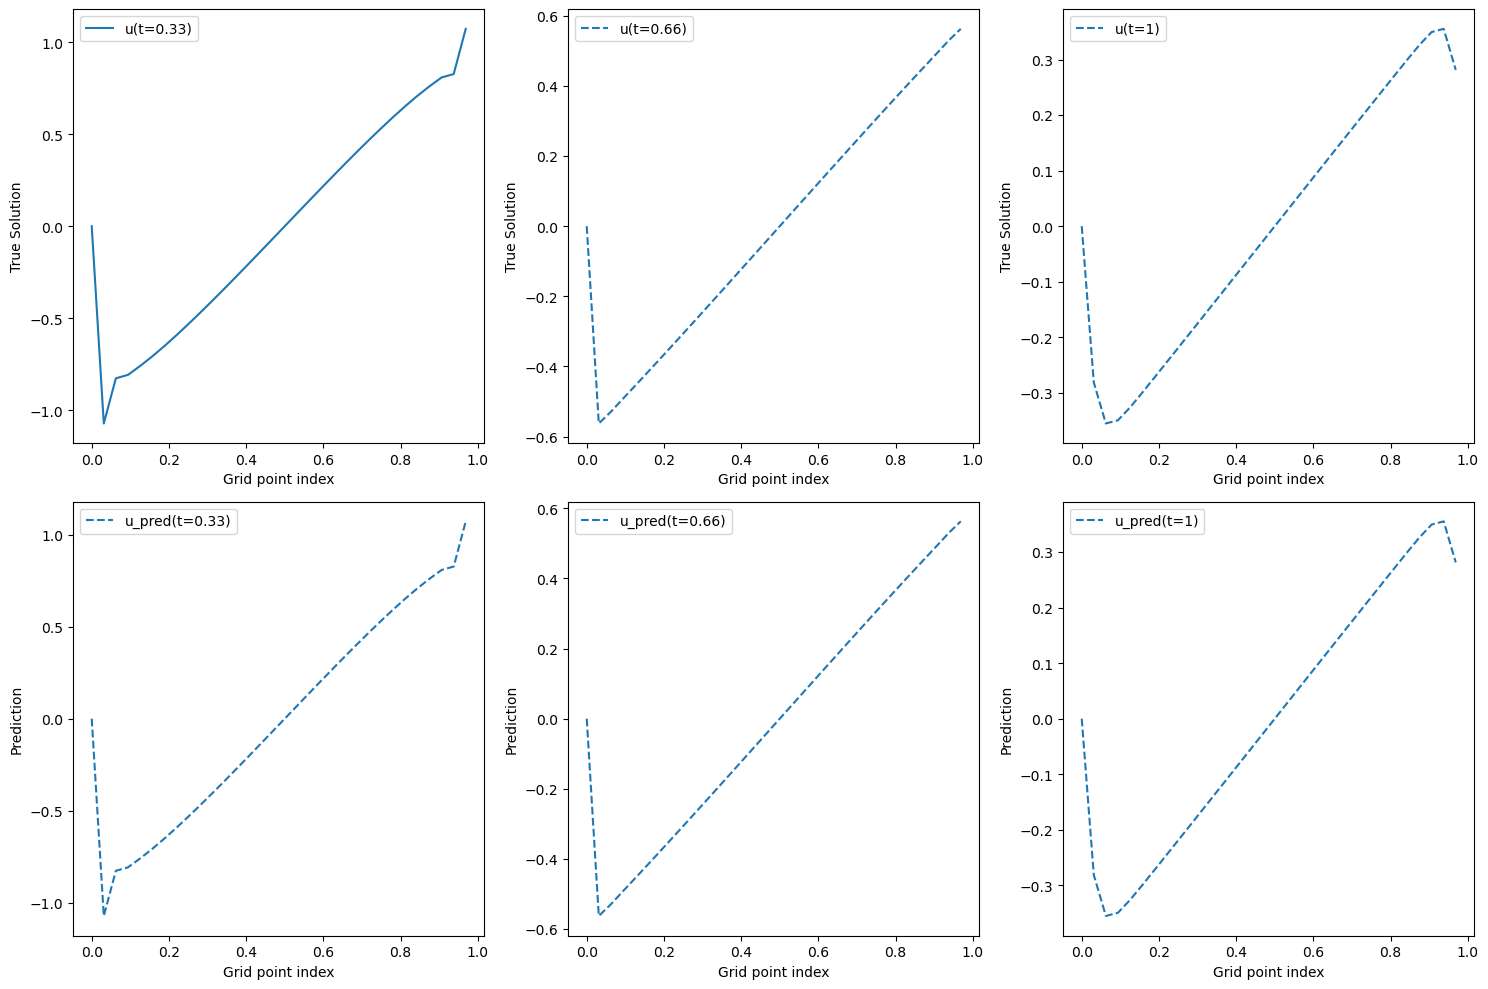

In [43]:
u0 = u_sol[:,30]
u1 = u_sol[:,66]
u2 = u_sol[:,99]
u3 = u_pred[:,30]
u4 = u_pred[:,66]
u5 = u_pred[:,99]

n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
# Plot true solution in the first column of the i-th row
axes[0,0].plot(x.numpy(), u0.detach().numpy(), label=f'u(t=0.33)')
axes[0,0].set_xlabel('Grid point index')
axes[0,0].set_ylabel('True Solution')
axes[0,0].legend()

# Plot GP means in the first column of the i-th row
axes[0,1].plot(x.numpy(), u1.detach().numpy(), label=f'u(t=0.66)', linestyle='--')
axes[0,1].set_xlabel('Grid point index')
axes[0,1].set_ylabel('True Solution')
axes[0,1].legend()

# Plot gradient decent solutions in the second column of the i-th row
axes[0,2].plot(x.numpy(), u2.detach().numpy(), label=f'u(t=1)', linestyle='--')
axes[0,2].set_xlabel('Grid point index')
axes[0,2].set_ylabel('True Solution')
axes[0,2].legend()

# Plot fast gradient solutions in the second column of the i-th row
axes[1,0].plot(x.numpy(), u3.detach().numpy(), label=f'u_pred(t=0.33)', linestyle='--')
axes[1,0].set_xlabel('Grid point index')
axes[1,0].set_ylabel('Prediction')
axes[1,0].legend()

# Plot classic Newton solution in the second column of the i-th row
axes[1,1].plot(x.numpy(), u4.detach().numpy(), label=f'u_pred(t=0.66)', linestyle='--')
axes[1,1].set_xlabel('Grid point index')
axes[1,1].set_ylabel(f'Prediction')
axes[1,1].legend()

# Plot classic Newton solution in the second column of the i-th row
axes[1,2].plot(x.numpy(), u5.detach().numpy(), label=f'u_pred(t=1)', linestyle='--')
axes[1,2].set_xlabel('Grid point index')
axes[1,2].set_ylabel(f'Prediction')
axes[1,2].legend()

plt.tight_layout() 
plt.show()

In [44]:
time = 99
rl2error = (torch.norm(u_sol[:, time] - u_pred[:, time]) / torch.norm(u_sol[:,time]))
l2error = torch.norm(u_sol[:,time] - u_pred[:,time])

print(f"Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")

Total Rel. L2 err: 4.3777798357300644e-16, Total L2 err: 5.579826354313191e-16


In [56]:
# Generating Solutions using the GP sampled data
num_test_data = 10

# f_test, u_test, a_test = generate_dataset_from_gp(num_test_data, N, periodic_kernel, length_scale=6.28, x=x)

f_test, u_test = generate_f_u_from_gp(num_test_data, N, periodic_kernel, length_scale=2, x=x)

# f_vals1 = torch.cat([(-A_L @ u_test[i, :] + Factor2 * u_test[i, :] ** 3).unsqueeze(0)
#                      for i in range(u_test.size(0))], dim=0)

# a = a_realizations[1]


# Loop through each realization
for j in range(num_test_data):
    
    u0 = u_test[j]

    u_sol = time_forward_method_classic(f, u0, A_laplace, max_iter=50, learning_rate=1.0)
    u_pred = time_forward_method_deep(gp_model[0], N, N_T, u = f, u0 = u0, A_laplace = A_laplace, max_iter=20, c1=1e-4, beta=0.3, learning_rate=1) 
        
    # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(u_sol - u_pred) / torch.norm(u_sol))
    l2error = torch.norm(u_sol - u_pred) 
    
    
    print(f"{j}, Deep Newton: Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")

0, Deep Newton: Total Rel. L2 err: 1.2521398307799924e-16, Total L2 err: 2.1692481346124617e-15
1, Deep Newton: Total Rel. L2 err: 1.722274089271085e-16, Total L2 err: 1.0131659552703306e-14
2, Deep Newton: Total Rel. L2 err: 3.0318285599893713e-16, Total L2 err: 6.7090439342853046e-15
3, Deep Newton: Total Rel. L2 err: 1.0577085575010963e-16, Total L2 err: 4.4106046277428444e-15
4, Deep Newton: Total Rel. L2 err: 1.5252874633520744e-16, Total L2 err: 2.753632986167285e-15
5, Deep Newton: Total Rel. L2 err: 1.3931571733361442e-16, Total L2 err: 3.822915821471459e-15
6, Deep Newton: Total Rel. L2 err: 1.3332287433159847e-16, Total L2 err: 6.749172418749388e-15
7, Deep Newton: Total Rel. L2 err: 1.2965490105590255e-16, Total L2 err: 2.4877458832829297e-15
8, Deep Newton: Total Rel. L2 err: 5.504572863579295e-08, Total L2 err: 4.829612910431465e-06
9, Deep Newton: Total Rel. L2 err: 1.8198456065792406e-16, Total L2 err: 5.440348217604472e-15


In [8]:
# Generating Solutions using the GP sampled data
num_test_data = 1
N_T = 100
A_laplace = laplacian_matrix(N, dx)
zero = torch.zeros(N)  

# We randomly generate the endpoints of a function and propagate backwards through the numerical scheme to obtain the whole solution and the initial condition. For the moment we don't use a rhs f

f_rhs, u_T = generate_f_u_from_gp(num_test_data, N, periodic_kernel, length_scale=0.2, x=x)

v_solutions = torch.zeros((num_test_data, N, N_T))
v_solutions[:, :, N_T-1] = u_T

for j in range(num_test_data):
    for i in range(N_T-1):
    
        C = convection_matrix(v_solutions[j, :, N_T-1-i], N, dx)
        v_solutions[j, :, N_T-2-i] = residual(v_solutions[j, :, N_T-1-i], zero, L, C, dt)

# 
# f_vals1 = torch.cat([(-A_laplace @ u_realizations[i, :] + Factor * u_realizations[i, :] ** 3).unsqueeze(0)
#                      for i in range(u_realizations.size(0))], dim=0)


# Initialize a variable to accumulate the relative errors
relative_error_sum = 0.0
error_sum = 0.0


# Loop through each realization
for j in range(num_test_data):
    
    u0 = v_solutions[j, :, 0]

    # v_predict = deep_newton_method_line_search_with_cubic(gp_model[0],  f_vals2[j,:], u0, A_laplace, max_iter=200, c1 = 1e-4, learning_rate = 1, epsilon=1e-8)
    # v_predict = deep_newton_method_line_search(gp_model[0], f_vals2[j,:], u0, A_laplace, max_iter = 300, c1 = 1e-4, beta = 0.3, learning_rate = 1)
    
    v_predict = time_forward_method_deep(gp_model[0], N, N_T, u = zero, u0 = u0, A_laplace = A_laplace, max_iter=50, c1=1e-4, beta=0.3, learning_rate=1)

    # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(v_solutions[j, :, :] - v_predict) / torch.norm(v_solutions[j, :]))
    l2error = torch.norm(v_solutions[j, :, :] - v_predict)

    print(f"Iteration {j}, Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")

    # Calculate the squared relative L2 error for the current realization
    rl2error = rl2error ** 2
    l2error = l2error ** 2

    # Accumulate the error
    relative_error_sum += rl2error.item()
    error_sum += l2error.item()

# Calculate the mean relative error by dividing by the number of realizations
mean_relative_error = relative_error_sum / num_test_data
mean_error = error_sum / num_test_data

# Take the square root
sqrt_mean_relative_error = mean_relative_error ** 0.5
sqrt_mean_error = mean_error ** 0.5

print(f"Total Rel. L2 err: {mean_relative_error}, Total L2 err: {mean_error}, Lambda = {lambda_reg}")
print(f"Total Rel. L2 err: {mean_relative_error ** 4}, Total L2 err: {mean_error}, Lambda = {lambda_reg}")


TypeError: unsupported operand type(s) for @: 'float' and 'Tensor'

tensor([-0.2876,  0.1138, -0.1102, -0.4373,  0.4636,  0.0530, -0.3610, -0.0083,
         0.6174, -0.0876,  0.6303, -0.4547,  0.6616, -0.0422, -0.4403, -0.3145,
         0.1482,  0.1910,  0.3896, -0.9591, -0.3405, -0.4319, -0.7299, -0.1974,
        -0.6090,  0.1806, -0.6849, -0.8127, -0.2402,  0.1752, -0.1397, -0.3383,
         0.0903, -0.0629,  0.2934,  0.1428,  0.5055, -0.7280,  0.1743,  0.9315,
         0.1173,  0.0663,  0.5040,  0.0017, -0.1983,  0.0202, -0.0914,  0.2178,
        -0.1552, -0.2669, -0.3225,  0.3542,  0.5598,  0.1942, -0.3162, -0.0465,
         0.4933,  0.7402, -0.3787, -0.3710,  0.3132, -0.4840, -0.1906,  0.1742,
         0.2616,  0.0410, -0.4896, -0.1260, -0.1707,  0.1322,  0.5870, -0.2741,
        -0.2479, -0.3016,  0.0193, -0.7538, -0.3443,  0.2513, -0.2543, -0.1612,
         0.0204,  0.0149,  0.0386,  0.3713, -0.3301,  0.5473,  0.0524,  0.7723,
         0.3746, -0.0061,  0.2259, -0.1258, -0.2128, -0.7516, -0.7176, -0.0644,
         0.3875, -0.0017,  0.6761, -0.23